# 5 · How Trading Works: Order Book, Spread and Price Impact

Backtests assume you trade at "the price". In reality there is no single price. There is a queue of buyers and sellers, and trading against that queue costs money. This notebook explains where trading costs come from and how to estimate them from data.

## 1. Motivation

A pension fund wants to sell &#36;50 million of a stock today. The screen shows &#36;100.00. Will it receive &#36;50 million? No. Its sell order uses up the buyers willing to pay &#36;100.00, then the ones at &#36;99.99, then &#36;99.98, and so on. The bigger the order, the worse the average price. For a small student portfolio this barely matters. For any strategy that trades often or trades large size, it can be the difference between profit and loss.

## 2. Intuition

Most exchanges run a continuous two-sided auction called the **limit order book**:

- A **limit order** says "I will buy (or sell) up to this quantity, at this price or better." It waits in the book.
- The highest waiting buy price is the **bid**. The lowest waiting sell price is the **ask**. The gap between them is the **bid–ask spread**.
- A **market order** says "trade now at whatever price is available." It takes liquidity from the book. If it is larger than the quantity at the best price, it **walks the book** to worse prices.

Think of a deli counter with a queue. The spread is the toll for crossing the counter right now instead of waiting. The **price impact** is the extra cost of a large order that has to work its way through the queue.

Two kinds of cost follow:
1. **Spread cost**: paid on every trade, even a tiny one.
2. **Impact cost**: grows with order size relative to how much normally trades.

## 3. The math

**Mid-price and spread.** With best bid $b$ and best ask $a$:
$$
m = \frac{a+b}{2}, \qquad s = a - b, \qquad \text{relative spread} = \frac{s}{m}.
$$
Buying with a market order costs about half the spread relative to the mid: $a - m = s/2$.

**Walking the book.** A market buy of size $Q$ fills $q_1$ shares at the best ask $p_1$, then $q_2$ at $p_2$, and so on, until $Q$ is filled. The average price is
$$
\bar P(Q) = \frac{1}{Q}\sum_{k} p_k\, q_k ,
$$
where the last level is only partly used. **Price impact** is $\bar P(Q) - m$, the cost compared with the mid-price.

**Measuring illiquidity from daily data.** We don't have order-book data for our stocks, but we have daily returns and volume. The **Amihud measure** asks *how much does the price move per dollar traded?*
$$
\text{ILLIQ} = \frac{1}{T}\sum_{t=1}^{T} \frac{|R_t|}{\text{DollarVolume}_t}, \qquad \text{DollarVolume}_t = P_t \times \text{Volume}_t .
$$
A large ILLIQ means a small amount of trading moves the price a lot: the stock is **illiquid**.

**The square-root law.** Across many markets, the impact cost of an order of size $Q$ is well described by
$$
\text{Impact} \approx Y\,\sigma_{\text{daily}}\,\sqrt{\frac{Q}{\text{ADV}}},
$$
where ADV is the average daily dollar volume and $Y$ is a constant close to 1. Trading 1% of a day's volume costs about $0.1\,\sigma_{\text{daily}}$, and trading 100× more costs only 10× more, not 100×.

## 4. Code it

### 4.1 Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

prices = pd.read_csv("../data/prices.csv", index_col="date", parse_dates=True)
volume = pd.read_csv("../data/volume.csv", index_col="date", parse_dates=True)
meta = pd.read_csv("../data/meta.csv")

COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
plt.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 100, "axes.prop_cycle": plt.cycler(color=COLORS),
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": 0.3, "lines.linewidth": 1.5, "font.size": 11,
})

### 4.2 A small order book

We write down a snapshot of a book by hand. Each row is one price level and the number of shares waiting there.

Bid 99.99, ask 100.01, mid 100.000, spread 0.02 (2.0 basis points)


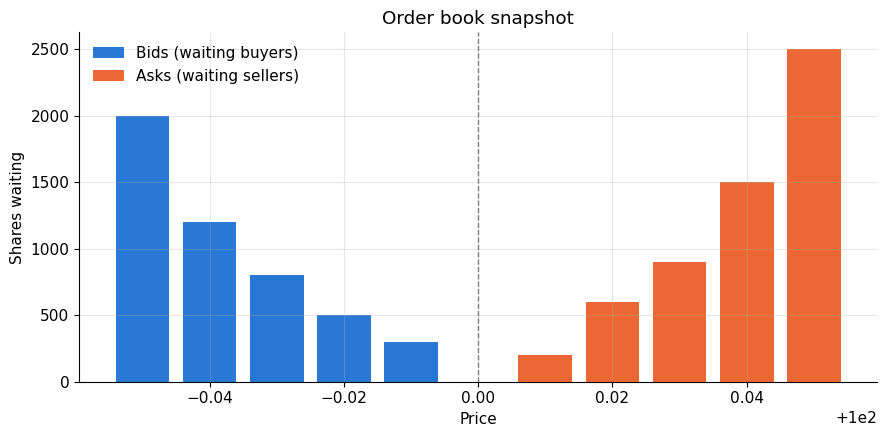

In [2]:
bids = pd.DataFrame({"price": [99.99, 99.98, 99.97, 99.96, 99.95],
                     "qty":   [  300,   500,   800,  1200,  2000]})
asks = pd.DataFrame({"price": [100.01, 100.02, 100.03, 100.04, 100.05],
                     "qty":   [   200,    600,    900,   1500,   2500]})

best_bid, best_ask = bids.price.max(), asks.price.min()
mid = (best_bid + best_ask) / 2                 # m = (a + b) / 2
spread = best_ask - best_bid                    # s = a - b
print(f"Bid {best_bid}, ask {best_ask}, mid {mid:.3f}, spread {spread:.2f} "
      f"({spread / mid * 1e4:.1f} basis points)")

fig, ax = plt.subplots()
ax.bar(bids.price, bids.qty, width=0.008, color=COLORS[0], label="Bids (waiting buyers)")
ax.bar(asks.price, asks.qty, width=0.008, color=COLORS[1], label="Asks (waiting sellers)")
ax.axvline(mid, color="grey", ls="--", linewidth=1)
ax.set_xlabel("Price")
ax.set_ylabel("Shares waiting")
ax.set_title("Order book snapshot")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

One **basis point** (bp) is 0.01%. Trading costs are almost always quoted in basis points.

### 4.3 Walking the book

This function implements $\bar P(Q) = \frac{1}{Q}\sum_k p_k q_k$ for a market buy order.

In [3]:
def average_buy_price(asks, Q):
    """Average fill price for a market BUY of Q shares, walking up the ask side."""
    remaining, cost = Q, 0.0
    for price, qty in zip(asks.price, asks.qty):   # best (lowest) ask first
        take = min(remaining, qty)                  # use this level fully, or only what we still need
        cost += take * price
        remaining -= take
        if remaining == 0:
            return cost / Q
    raise ValueError("Order is larger than the visible book")

for Q in [100, 1000, 3000, 5000]:
    p = average_buy_price(asks, Q)
    print(f"Buy {Q:>5} shares: average price {p:.4f}, impact vs mid {(p - mid) / mid * 1e4:5.1f} bp")

Buy   100 shares: average price 100.0100, impact vs mid   1.0 bp
Buy  1000 shares: average price 100.0200, impact vs mid   2.0 bp
Buy  3000 shares: average price 100.0310, impact vs mid   3.1 bp
Buy  5000 shares: average price 100.0382, impact vs mid   3.8 bp


A 100-share order fills entirely at the best ask, so it pays only half the spread (1 bp). A 5,000-share order has to reach the fourth price level and pays almost 4 bp. In this small example the numbers are tiny. They grow quickly when the book is thin compared with the order.

### 4.4 Amihud illiquidity on real data

We now compute ILLIQ for every stock and ETF in the dataset. The raw numbers are tiny, so we multiply by $10^9$: the result is the average price move, in percent, per &#36;10 million traded.

In [4]:
tickers = meta.loc[meta.asset_type != "index", "ticker"]
ret = prices[tickers].pct_change()
dollar_vol = prices[tickers] * volume[tickers]           # DollarVolume_t = P_t x Volume_t

recent = ret.index >= "2024-01-01"                         # use the last ~3 years
illiq = (ret[recent].abs() / dollar_vol[recent]).mean() * 1e9   # Amihud, scaled
adv = dollar_vol[recent].mean()                            # average daily dollar volume

liq = pd.DataFrame({"ILLIQ (% per $10M)": illiq, "ADV ($M)": adv / 1e6}).sort_values("ILLIQ (% per $10M)")
print("Most liquid:")
print(liq.head(5).round({"ILLIQ (% per $10M)": 4, "ADV ($M)": 0}))
print("\nLeast liquid:")
print(liq.tail(5).round({"ILLIQ (% per $10M)": 4, "ADV ($M)": 0}))

Most liquid:
      ILLIQ (% per $10M)  ADV ($M)
SPY               0.0002   38983.0
QQQ               0.0004   24470.0
NVDA              0.0006   33915.0
HYG               0.0007    2874.0
AAPL              0.0009   12580.0

Least liquid:
     ILLIQ (% per $10M)  ADV ($M)
VNQ              0.0236     319.0
AMT              0.0242     494.0
SLB              0.0258     604.0
PLD              0.0260     448.0
APD              0.0310     371.0


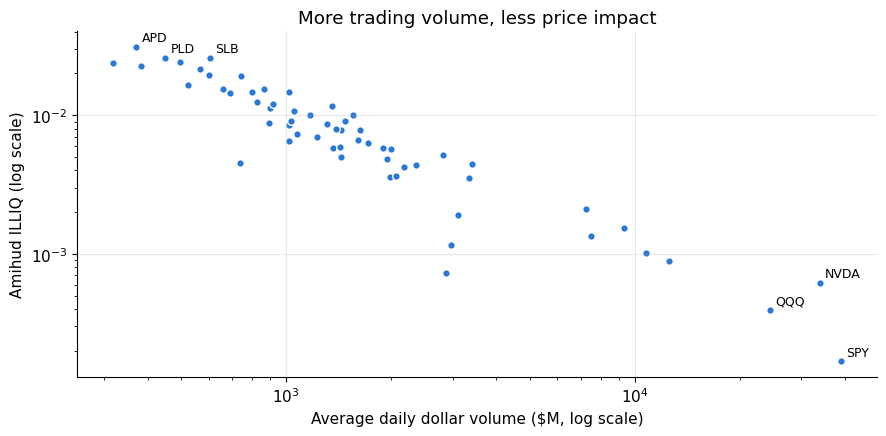

In [5]:
fig, ax = plt.subplots()
ax.scatter(liq["ADV ($M)"], liq["ILLIQ (% per $10M)"], s=30, color=COLORS[0],
           edgecolor="white", linewidth=1)
for t in list(liq.index[:3]) + list(liq.index[-3:]):     # label the extremes only
    ax.annotate(t, (liq.loc[t, "ADV ($M)"], liq.loc[t, "ILLIQ (% per $10M)"]),
                xytext=(4, 4), textcoords="offset points", fontsize=9)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Average daily dollar volume ($M, log scale)")
ax.set_ylabel("Amihud ILLIQ (log scale)")
ax.set_title("More trading volume, less price impact")
plt.tight_layout()
plt.show()

The ranking matches what you would expect. SPY, QQQ, NVDA and AAPL trade tens of billions of dollars a day and barely move per &#36;10M traded. Mid-sized names such as Air Products (APD), Prologis (PLD) and the real-estate ETF VNQ are **more than 100 times less liquid** than SPY by this measure. The scatter plot shows the general rule: illiquidity falls steeply as dollar volume rises.

### 4.5 What would an order cost? The square-root law

We use $\text{Impact} \approx \sigma_{\text{daily}}\sqrt{Q/\text{ADV}}$ (with $Y = 1$) to estimate the cost of different order sizes in three very different instruments.

In [6]:
sigma_daily = ret[recent].std()

rows = {}
for t in ["SPY", "AAPL", liq.index[-1]]:                    # very liquid ETF, big stock, least liquid name
    for Q in [1e6, 10e6, 100e6]:                             # order size in dollars
        impact = sigma_daily[t] * np.sqrt(Q / adv[t])         # square-root law
        rows[(t, f"${Q / 1e6:.0f}M")] = impact * 1e4          # in basis points
cost = pd.Series(rows).unstack()[["$1M", "$10M", "$100M"]].round(1)
print("Estimated impact cost (basis points):")
cost

Estimated impact cost (basis points):


,$1M,$10M,$100M
AAPL,1.6,4.9,15.5
APD,8.8,27.9,88.2
SPY,0.5,1.6,5.0


For a typical student-sized order (&#36;1M or less), costs are a few basis points at most. At &#36;100M, trading APD in one day would cost almost 0.9%, enough to wipe out the expected profit of most strategies. Note also the square-root shape: each row grows by about $\sqrt{10} \approx 3.2\times$ for each 10× increase in order size.

## 5. Takeaways and where it breaks

- **There is no single price.** You buy at the ask and sell at the bid. Every round trip costs at least one spread.
- **Big orders cost more per share.** Impact grows roughly with the square root of order size relative to daily volume.
- **Liquidity varies a lot.** Big ETFs and mega-caps are cheap to trade. Smaller names can be many times more expensive.
- **Where it breaks:** Amihud is a rough proxy computed from daily data. It mixes price moves caused by news with moves caused by trading. The square-root law is an empirical average with large uncertainty, and $Y$ differs by market and by trader.
- **The book changes.** Real books refill after a trade, which is why large orders are split up and traded over hours or days.

**What you could build:** a liquidity screen that estimates the cost of trading any ticker at a given size. Every team can use it to drop strategies that only work on paper.